<a href="https://colab.research.google.com/github/Ginkno/postech-tech-challenge-fase2-grupo1-12dtat/blob/Elizabeth/notebooks/%2001_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 — Análise Exploratória de Dados

**Dimensão 3 da rúbrica — 20 pontos.**

Toda visualização precisa de um parágrafo de interpretação logo abaixo.
Gráfico sem leitura perde metade dos pontos do critério.

In [163]:
#Libs - Bibliotecas importantes

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np


# Semente fixa: use em TODO ponto com aleatoriedade (split, modelos, CV).
RANDOM_STATE = 42

RAW_1 = Path("../data/raw/application_record.csv")
RAW_2 = Path("../data/raw/credit_record.csv")


PROCESSED = Path("..") / "data" / "processed"
TARGET = "TARGET"

pd.set_option("display.max_columns", None)

In [164]:
#Leitura do dataframe e visualização das cinco primeiras linhas.

df_application = pd.read_csv(RAW_1)
df_application.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


Leitura do dataframe e visualização das cinco primeiras linhas.

## 1. Visão geral

_Dimensões, tipos e primeira impressão do dataset._

In [165]:
print(f"Tamanho do df_application: {df_application.shape}")

Tamanho do df_application: (438557, 18)


In [166]:
#Visualizar os tipos das variáveis.

df_application.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

O df_application possui 438557 registros e 18 colunas. Ao analisar os tipos de dados com o comando .info(), observamos que há 02 variáveis tipo float, 8 tipo int e 08 como texto (tipo object).

In [167]:
#Verificando a existência de dados nulos.

df_application.isnull().sum()

ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64

Verificando a existência de dados nulos e como resultado trouxe que a coluna OCCUPATION_TYPE possui 134203 linhas em branco.

In [168]:
#Substituir os dados em branco da variável OCCUPATION_TYPE por "Unknown".

df_application["OCCUPATION_TYPE"] = df_application["OCCUPATION_TYPE"].fillna("Unknown")

In [169]:
#Verificando a existência de dados duplicados.

df_application.duplicated().sum()

np.int64(0)

Verificando a existência de dados duplicados e como resultado trouxe que a quantidade de dados duplicados é 0.

In [170]:
print(f"Quantidade de IDs únicos em df_application: {df_application['ID'].nunique()}")

Quantidade de IDs únicos em df_application: 438510


In [171]:
#Verificando a existência de IDs duplicados.

df_application["ID"].duplicated().sum()

np.int64(47)

In [172]:
#Para os IDs duplicados, verificar se os dados das outras variáveis estão duplicados também.

duplicados = df_application[df_application["ID"].duplicated(keep=False)]
duplicados.sort_values(by="ID")


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
425023,7022197,F,N,Y,0,450000.0,Commercial associate,Higher education,Separated,House / apartment,-19813,-1799,1,0,0,1,Unknown,1.0
426818,7022197,M,Y,Y,3,135000.0,Working,Secondary / secondary special,Married,House / apartment,-11945,-735,1,0,0,1,Laborers,5.0
431911,7022327,M,Y,Y,0,256500.0,Commercial associate,Higher education,Married,House / apartment,-21503,-1674,1,0,0,1,Core staff,2.0
431545,7022327,F,N,Y,0,135000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-14771,-5298,1,0,0,0,High skill tech staff,1.0
425486,7023108,M,Y,Y,1,67500.0,Working,Secondary / secondary special,Married,House / apartment,-15156,-1696,1,1,0,0,Core staff,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426563,7836711,F,N,Y,2,292500.0,Working,Higher education,Married,House / apartment,-13747,-4386,1,0,1,0,Accountants,4.0
428620,7836971,F,N,Y,0,103500.0,Working,Secondary / secondary special,Civil marriage,House / apartment,-13383,-2798,1,0,1,0,Sales staff,2.0
421464,7836971,M,Y,N,1,157500.0,Working,Secondary / secondary special,Married,House / apartment,-13771,-5520,1,0,0,0,Unknown,3.0
422068,7838075,M,N,Y,0,337500.0,Commercial associate,Secondary / secondary special,Married,House / apartment,-18198,-1275,1,0,0,1,Drivers,2.0


Foram identificados 47 IDs repetidos com informações divergentes nas demais variáveis. Como não foi possível determinar qual registro representa a informação mais atual ou correta, optou-se por manter os registros para análise posterior.

In [173]:
# Lista de colunas sem a coluna ID

cols_sem_id = df_application.columns.drop('ID')

# Linhas consideradas duplicadas ignorando o ID

duplicadas = df_application[df_application.duplicated(subset=cols_sem_id, keep=False)]

print(f"Quantidade de linhas duplicadas (ignorando ID): {len(duplicadas)}")

duplicadas.sort_values(by=list(cols_sem_id))

Quantidade de linhas duplicadas (ignorando ID): 423253


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
273113,6093713,F,N,N,0,26100.0,Pensioner,Secondary / secondary special,Married,House / apartment,-21003,365243,1,0,0,0,Unknown,2.0
436891,6093712,F,N,N,0,26100.0,Pensioner,Secondary / secondary special,Married,House / apartment,-21003,365243,1,0,0,0,Unknown,2.0
92482,5369432,F,N,N,0,27000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-20794,365243,1,0,0,0,Unknown,2.0
92483,5369433,F,N,N,0,27000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-20794,365243,1,0,0,0,Unknown,2.0
92484,5369434,F,N,N,0,27000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-20794,365243,1,0,0,0,Unknown,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84129,5342638,M,Y,Y,5,810000.0,Working,Secondary / secondary special,Married,House / apartment,-14914,-2593,1,0,0,0,Laborers,7.0
84130,5342639,M,Y,Y,5,810000.0,Working,Secondary / secondary special,Married,House / apartment,-14914,-2593,1,0,0,0,Laborers,7.0
20441,5061207,M,Y,Y,14,225000.0,Working,Secondary / secondary special,Separated,House / apartment,-17754,-1689,1,0,0,0,Drivers,15.0
20442,5061210,M,Y,Y,14,225000.0,Working,Secondary / secondary special,Separated,House / apartment,-17754,-1689,1,0,0,0,Drivers,15.0


In [174]:
#Quantas linhas são repetidas, ignorando a variável 'ID'.

df_application.duplicated(subset=df_application.columns.drop('ID')).sum()

np.int64(348472)

O resultado indica que existem 348.472 linhas com valores exatamente iguais nas demais colunas, mesmo que possuam IDs diferentes, porém não podemos determinar se são pessoas iguais ou diferentes. O fato de terem as mesmas características não as torna o mesmo cliente.

In [175]:
#Analisar a variável DAYS_EMPLOYED com o valor 365243.

(df_application["DAYS_EMPLOYED"] ==365243).sum()

np.int64(75329)

São 75329 linhas que aparecem o valor 365243. Conforme dicionário de dados disponibilizado significa pessoas desempregadas.

In [176]:
#Identificar padrão.

df_application.loc[df_application["DAYS_EMPLOYED"] == 365243, ["DAYS_EMPLOYED", "OCCUPATION_TYPE"]]

,DAYS_EMPLOYED,OCCUPATION_TYPE
7,365243,Unknown
8,365243,Unknown
9,365243,Unknown
76,365243,Unknown
160,365243,Unknown
...,...,...
438549,365243,Unknown
438550,365243,Unknown
438551,365243,Unknown
438552,365243,Unknown


Os dados nulos na variável OCCUPATION_TYPE foram substituídos por "Unknown". Código gerado para analisar a relação entre essas duas variáveis com o registro 365243.

In [177]:
#Identificar padrão.

df_application.loc[df_application["DAYS_EMPLOYED"] == 365243, "NAME_INCOME_TYPE",].value_counts()

NAME_INCOME_TYPE
Pensioner    75329
Name: count, dtype: int64

Ao analisar a variável DAYS_EMPLOYED, observou-se a ocorrência de 75.329 registros com o valor 365243. O cruzamento dessa informação com a variável NAME_INCOME_TYPE mostrou que todos esses registros correspondem à categoria Pensioner (aposentados/pensionistas). De acordo com o dicionário de dados da base, valores positivos em DAYS_EMPLOYED devem ser interpretados como indivíduos sem vínculo empregatício ativo. No entanto, é importante destacar que os pensionistas possuem uma fonte de renda previdenciária regular, o que os diferencia de indivíduos efetivamente desempregados. Portanto, o valor 365243 aparenta representar um código especial utilizado para identificar beneficiários de aposentadoria ou pensão, e não necessariamente a ausência de renda. Essa característica deve ser considerada durante as etapas de tratamento e interpretação dos dados para evitar conclusões equivocadas sobre a situação financeira desses clientes.

In [178]:
#Converter dias de nascimento para idade em anos e para inteiro.
df_application["YEARS_BIRTH"] = (df_application["DAYS_BIRTH"] / -365).astype(int)

#Criar a coluna IS_INACTIVE (1 para inativo, 0 para empregado).
df_application["IS_INACTIVE"] = (df_application["DAYS_EMPLOYED"] == 365243).astype(int)

#Converter dias de emprego para anos.
df_application["YEARS_EMPLOYED"] = (df_application["DAYS_EMPLOYED"] / -365 ).astype(int)

In [179]:
df_application.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,YEARS_BIRTH,IS_INACTIVE,YEARS_EMPLOYED
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,32,0,12
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,32,0,12
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,58,0,3
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,52,0,8
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,52,0,8


In [180]:
# Contar quantas vezes o valor -1000 aparece em YEARS_EMPLOYED
count_minus_1000 = (df_application['YEARS_EMPLOYED'] == -1000).sum()
print(f"Quantidade de registros com YEARS_EMPLOYED == -1000: {count_minus_1000}")

# Verificar a relação entre YEARS_EMPLOYED == -1000 e IS_INACTIVE
print("Verificando se -1000 em YEARS_EMPLOYED corresponde a IS_INACTIVE == 1:")
display(df_application.loc[df_application['YEARS_EMPLOYED'] == -1000, 'IS_INACTIVE'].value_counts())

Quantidade de registros com YEARS_EMPLOYED == -1000: 75329
Verificando se -1000 em YEARS_EMPLOYED corresponde a IS_INACTIVE == 1:


IS_INACTIVE
1    75329
Name: count, dtype: int64

Como esperado, o valor `-1000` em `YEARS_EMPLOYED` corresponde exatamente aos registros onde `IS_INACTIVE` é `1`, ou seja, aos 'pensionistas/inativos'. Para facilitar a análise e a modelagem, substituiremos esse valor por `0`, indicando zero anos de emprego ativo, o que é consistente com a definição de inatividade.

In [181]:
# Substituir -1000 em YEARS_EMPLOYED por 0
df_application['YEARS_EMPLOYED'] = df_application['YEARS_EMPLOYED'].replace(-1000, 0)

# Verificar as primeiras linhas após a substituição
print("df_application.head() após substituição de -1000 por 0:")
display(df_application.head())

df_application.head() após substituição de -1000 por 0:


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,YEARS_BIRTH,IS_INACTIVE,YEARS_EMPLOYED
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,32,0,12
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,32,0,12
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,58,0,3
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,52,0,8
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,52,0,8


In [182]:
#Leitura do dataframe e visualização das cinco primeiras linhas.
df_credit = pd.read_csv(RAW_2)
df_credit.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


Conforme dicionário de dados disponibilizado: 0: 1-29 dias atrasados; 1: 30-59 dias atrasados; 2: 60-89 dias atrasados; 3: 90-119 dias atrasados; 4: 120-149 dias atrasados; 5: dívidas atrasadas ou incobráveis, perdas por mais de 150 dias; C: quitadas naquele mês; X: sem empréstimo no mês;

In [183]:
print(f"Tamanho do df_credit: {df_credit.shape}")

Tamanho do df_credit: (1048575, 3)


In [184]:
#Visualizar os tipos das variáveis.

df_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


O df_credit possui 1048575 registros e 03 colunas. Ao analisar os tipos de dados com o comando .info(), observamos que há 02 variáveis tipo int e 01 como texto (tipo object).

In [185]:
#Verificando a existência de dados nulos.

df_credit.isnull().sum()

ID                0
MONTHS_BALANCE    0
STATUS            0
dtype: int64

Como resultado trouxe que a quantidade de dados nulos é 0.

In [186]:
#Verificando a existência de dados duplicados.

df_credit.duplicated().sum()

np.int64(0)

Como resultado trouxe que a quantidade de dados duplicados é 0.

In [187]:
#Verificando a existência de IDs duplicados.

df_credit["ID"].duplicated().sum()

np.int64(1002590)

Como resultado trouxe a quantidade 1002590 cópias.

In [188]:
duplicados = df_credit[df_credit["ID"].duplicated(keep=False)]
duplicados.sort_values(by="ID")

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C
...,...,...,...
1048562,5150487,-17,C
1048569,5150487,-24,C
1048567,5150487,-22,C
1048568,5150487,-23,C


1048176 representa o total de linhas que contem IDs que aparecem mais de uma vez, incluindo a primeira ocorrência de cada ID duplicado. Porém referem-se a meses diferentes.

In [189]:
print(df_credit['ID'].nunique())
print(len(df_credit))

45985
1048575


45985 IDs únicos do total de 1048575 IDs.

Para unir as informações de df_credit com as de df_application, é preciso consolidar o histórico de crédito de cada cliente (ID) em uma única linha.

Codificar a variável STATUS: Atribuir valores numéricos que reflitam o risco de crédito. Agregar por ID: Para cada cliente, obter a pontuação de risco máximo (pior status) e o número de meses no histórico (MONTHS_BALANCE).

In [190]:
# Criar uma cópia de df_credit para evitar modificar o original
df_status_agreggated = df_credit.copy()
# -------------------------------------------------------------------------
# 1. Mapeamento do Status para nível numérico de atraso
# -------------------------------------------------------------------------
# Consideramos atraso real os status 0, 1, 2, 3, 4, 5.
# X e C representam sem dívida / em dia (nível 0 de atraso).
status_map = {"X": 0, "C": 0, "0": 1, "1": 2, "2": 3, "3": 4, "4": 5, "5": 6}

# Garante texto limpo do status original
df_status_agreggated["STATUS_ORIGINAL"] = (
    df_status_agreggated["STATUS"].astype(str).str.strip()
)

# Cria a coluna numérica para gravidade do atraso (ex: WORST_LATE)
df_status_agreggated["STATUS_NUM"] = (
    df_status_agreggated["STATUS_ORIGINAL"]
    .map(status_map)
    .fillna(0)
    .astype(int)
)

# Flag booleana: verifica os caracteres ORIGINAIS do status que representam atraso
df_status_agreggated["IS_LATE"] = df_status_agreggated[
    "STATUS_ORIGINAL"
].isin(["0", "1", "2", "3", "4", "5"])
# -------------------------------------------------------------------------
# 2. Filtragem de janelas de tempo (últimos N meses)
# -------------------------------------------------------------------------
# Como months_balance vai de 0 (mais recente) a negativos (-1, -2, ...),
# filtramos pelo valor absoluto do mês.
df_3m = df_status_agreggated[df_status_agreggated["MONTHS_BALANCE"] >= -2]  # Últimos 3 meses (0, -1, -2)
df_6m = df_status_agreggated[df_status_agreggated["MONTHS_BALANCE"] >= -5]  # Últimos 6 meses
df_9m = df_status_agreggated[df_status_agreggated["MONTHS_BALANCE"] >= -8]  # Últimos 9 meses
df_12m = df_status_agreggated[df_status_agreggated["MONTHS_BALANCE"] >= -11]  # Últimos 12 meses

# -------------------------------------------------------------------------
# 3. Criação das flags de atraso nas janelas (0 ou 1)
# -------------------------------------------------------------------------
late_3m = df_3m.groupby("ID")["IS_LATE"].any().astype(int).rename("LATE_3M")
late_6m = df_6m.groupby("ID")["IS_LATE"].any().astype(int).rename("LATE_6M")
late_9m = df_9m.groupby("ID")["IS_LATE"].any().astype(int).rename("LATE_9M")
late_12m = df_12m.groupby("ID")["IS_LATE"].any().astype(int).rename("LATE_12M")

# -------------------------------------------------------------------------
# 4. Pior histórico de atraso (WORST_LATE)
# -------------------------------------------------------------------------
# Pega o maior nível numérico de atraso e mapeia de volta para a flag original
worst_num = df_status_agreggated.groupby("ID")["STATUS_NUM"].max()
num_to_status = {0: "C", 1: "0", 2: "1", 3: "2", 4: "3", 5: "4", 6: "5"}
worst_late = worst_num.map(num_to_status).rename("WORST_LATE")

# -------------------------------------------------------------------------
# 5. Recência do último atraso (LAST_LATE)
# -------------------------------------------------------------------------
# Filtramos apenas as linhas onde houve atraso e pegamos o mês mais recente (max no MONTHS_BALANCE)
df_lates_only = df_status_agreggated[df_status_agreggated["IS_LATE"] == True]
last_late_month = df_lates_only.groupby("ID")["MONTHS_BALANCE"].max()

# A distância em meses até o presente (mês 0) é |MONTHS_BALANCE|
# Se o cliente nunca atrasou, atribuímos um valor alto (ex: 999 ou NaN)
last_late = (last_late_month.abs()).rename("LAST_LATE")

# Total de meses de histórico do cliente
hist_length = (
    df_status_agreggated.groupby("ID")["MONTHS_BALANCE"].count().rename("HIST_LENGTH")
)

# Total absoluto de meses com atraso (Substitui com vantagem a métrica fracionária)
total_lates = df_status_agreggated.groupby("ID")["IS_LATE"].sum().rename("TOTAL_LATES")

# Proporção de meses com atraso (de 0.0 a 1.0)
late_rate = (total_lates / hist_length).rename("LATE_RATE")

# -------------------------------------------------------------------------
# 7. Consolidação em um DataFrame final único por ID
# -------------------------------------------------------------------------
# Pega a lista única de todos os IDs
df_features_behavior = pd.DataFrame(index=df_status_agreggated["ID"].unique()).sort_index()

# Unindo todas as métricas geradas
df_features_behavior = df_features_behavior.join(
    [late_3m, late_6m, late_9m, late_12m, worst_late, last_late, hist_length, total_lates, late_rate]
)

# Trata clientes sem histórico em janelas específicas ou sem atraso
df_features_behavior["LATE_3M"] = df_features_behavior["LATE_3M"].fillna(0).astype(int)
df_features_behavior["LATE_6M"] = df_features_behavior["LATE_6M"].fillna(0).astype(int)
df_features_behavior["LATE_9M"] = df_features_behavior["LATE_9M"].fillna(0).astype(int)
df_features_behavior["LATE_12M"] = df_features_behavior["LATE_12M"].fillna(0).astype(int)
df_features_behavior["WORST_LATE"] = df_features_behavior["WORST_LATE"].fillna("C")
df_features_behavior["LAST_LATE"] = df_features_behavior["LAST_LATE"].fillna(
    999
)  # 999 = Nunca atrasou

# Resetando o índice para deixar a coluna 'ID' normal
df_features_behavior = df_features_behavior.reset_index().rename(columns={"index": "ID"})

# Exibe os primeiros resultados
print("Histórico consolidado")
df_features_behavior.head(10)


Histórico consolidado


,ID,LATE_3M,LATE_6M,LATE_9M,LATE_12M,WORST_LATE,LAST_LATE,HIST_LENGTH,TOTAL_LATES,LATE_RATE
0,5001711,1,1,1,1,0,1.0,4,3,0.750000
1,5001712,0,0,0,1,0,9.0,19,10,0.526316
2,5001713,0,0,0,0,C,999.0,22,0,0.000000
3,5001714,0,0,0,0,C,999.0,15,0,0.000000
4,5001715,0,0,0,0,C,999.0,60,0,0.000000
5,5001717,0,1,1,1,0,5.0,22,17,0.772727
6,5001718,0,1,1,1,1,3.0,39,26,0.666667
7,5001719,0,0,0,0,0,41.0,43,2,0.046512
8,5001720,1,1,1,1,1,0.0,36,36,1.000000
9,5001723,0,0,0,0,0,22.0,31,8,0.258065


In [191]:
#Definição da variável alvo (target)

# 1. Extrair o Status do Mês Atual (balanco_meses == 0) por cliente
# -------------------------------------------------------------------------
# Pega a linha mais recente de cada cliente no dataframe original
df_current = (
    df_status_agreggated[df_status_agreggated["MONTHS_BALANCE"] == 0]
    .set_index("ID")["STATUS_ORIGINAL"]
    .rename("STATUS_CURRENT")
)

# Adiciona a coluna do status atual no seu df_features
df_features_behavior = df_features_behavior.set_index("ID").join(df_current).reset_index()
df_features_behavior["STATUS_CURRENT"] = df_features_behavior["STATUS_CURRENT"].fillna("C")


# -------------------------------------------------------------------------
# 2. Regra Logica para Definicao da TARGET Refinada
# -------------------------------------------------------------------------
def define_target(row):
    # Atrasos considerados graves
    bad_flags = ["2", "3", "4", "5"]

    status_atual = str(row["STATUS_CURRENT"])
    pior_atraso = str(row["WORST_LATE"])
    ultimo_atraso_meses = row["LAST_LATE"]
    tempo_historico = row["HIST_LENGTH"]
    taxa_atraso = row["LATE_RATE"]

    # --- CONDICIONAL 1: MAU PAGADOR (TARGET = 1) ---
    # 1.1 Está atualmente em atraso grave (mês 0)
    if status_atual in bad_flags:
        return 1

    # 1.2 Teve atraso grave RECENTE (ocorreu há 6 meses ou menos)
    if (pior_atraso in bad_flags) and (ultimo_atraso_meses <= 6):
        return 1

    # 1.3 Cliente com histórico curto (< 6 meses) que já teve atraso relevante
    if (tempo_historico < 6) and (pior_atraso in ["1", "2", "3", "4", "5"]):
        return 1

    # 1.4 Atrasou em mais de 40% de todo o seu histórico (comportamento crônico)
    if taxa_atraso > 0.40:
        return 1

    # --- CONDICIONAL 2: BOM PAGADOR / REABILITADO (TARGET = 0) ---
    # Se passou por todas as regras acima, está atualmente em dia e/ou
    # seu pior atraso ficou no passado distante com histórico maduro
    return 0


# Aplica a função linha por linha no dataframe de features
df_features_behavior["TARGET"] = df_features_behavior.apply(define_target, axis=1)

# Exibe o resultado e a proporção
print("--- Distribuição da Nova Variável Alvo (TARGET Refinada) ---")
print(df_features_behavior["TARGET"].value_counts(normalize=True) * 100)

--- Distribuição da Nova Variável Alvo (TARGET Refinada) ---
TARGET
1    51.721213
0    48.278787
Name: proportion, dtype: float64


A distribuição da variável alvo `TARGET` é aproximadamente equilibrada, com cerca de 53,45% de bons pagadores (`0`) e 46,55% de maus pagadores (`1`). Essa proporção reduz o risco de um modelo favorecer excessivamente uma classe, mas ainda exige avaliação por métricas além da acurácia.

In [192]:
# Mesclar df_application com df_features_behavior usando a coluna 'ID'
df_final = pd.merge(df_application, df_features_behavior, on='ID', how='inner')

# Exibir as primeiras linhas do dataframe final
print("Primeiras 5 linhas do df_final:")
display(df_final.head())

# Exibir o formato do dataframe final
print(f"Dimensão do df_final: {df_final.shape}")

Primeiras 5 linhas do df_final:


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,YEARS_BIRTH,IS_INACTIVE,YEARS_EMPLOYED,LATE_3M,LATE_6M,LATE_9M,LATE_12M,WORST_LATE,LAST_LATE,HIST_LENGTH,TOTAL_LATES,LATE_RATE,STATUS_CURRENT,TARGET
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,32,0,12,0,0,0,0,1,13.0,16,2,0.125000,C,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,32,0,12,0,0,0,0,1,12.0,15,2,0.133333,C,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,58,0,3,0,0,1,1,0,8.0,30,7,0.233333,C,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,52,0,8,1,1,1,1,0,0.0,5,2,0.400000,0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,52,0,8,0,0,0,0,C,999.0,5,0,0.000000,C,0


Dimensão do df_final: (36457, 32)


In [193]:
# Verificar informações gerais do df_final
print("\nInformações do df_final:")
df_final.info()


Informações do df_final:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   36457 non-null  int64  
 1   CODE_GENDER          36457 non-null  object 
 2   FLAG_OWN_CAR         36457 non-null  object 
 3   FLAG_OWN_REALTY      36457 non-null  object 
 4   CNT_CHILDREN         36457 non-null  int64  
 5   AMT_INCOME_TOTAL     36457 non-null  float64
 6   NAME_INCOME_TYPE     36457 non-null  object 
 7   NAME_EDUCATION_TYPE  36457 non-null  object 
 8   NAME_FAMILY_STATUS   36457 non-null  object 
 9   NAME_HOUSING_TYPE    36457 non-null  object 
 10  DAYS_BIRTH           36457 non-null  int64  
 11  DAYS_EMPLOYED        36457 non-null  int64  
 12  FLAG_MOBIL           36457 non-null  int64  
 13  FLAG_WORK_PHONE      36457 non-null  int64  
 14  FLAG_PHONE           36457 non-null  int64  
 15  FLAG_EMAIL

In [194]:
df_final.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,36457.0,5.078227e+06,41875.240788,5008804.0,5.042028e+06,5.074614e+06,5.115396e+06,5150487.0
CNT_CHILDREN,36457.0,4.303152e-01,0.742367,0.0,0.000000e+00,0.000000e+00,1.000000e+00,19.0
AMT_INCOME_TOTAL,36457.0,1.866857e+05,101789.226482,27000.0,1.215000e+05,1.575000e+05,2.250000e+05,1575000.0
DAYS_BIRTH,36457.0,-1.597517e+04,4200.549944,-25152.0,-1.943800e+04,-1.556300e+04,-1.246200e+04,-7489.0
DAYS_EMPLOYED,36457.0,5.926294e+04,137651.334859,-15713.0,-3.153000e+03,-1.552000e+03,-4.080000e+02,365243.0
FLAG_MOBIL,36457.0,1.000000e+00,0.000000,1.0,1.000000e+00,1.000000e+00,1.000000e+00,1.0
FLAG_WORK_PHONE,36457.0,2.255260e-01,0.417934,0.0,0.000000e+00,0.000000e+00,0.000000e+00,1.0
FLAG_PHONE,36457.0,2.948131e-01,0.455965,0.0,0.000000e+00,0.000000e+00,1.000000e+00,1.0
FLAG_EMAIL,36457.0,8.972214e-02,0.285787,0.0,0.000000e+00,0.000000e+00,0.000000e+00,1.0
CNT_FAM_MEMBERS,36457.0,2.198453e+00,0.911686,1.0,2.000000e+00,2.000000e+00,3.000000e+00,20.0


## 2. Distribuição das variáveis

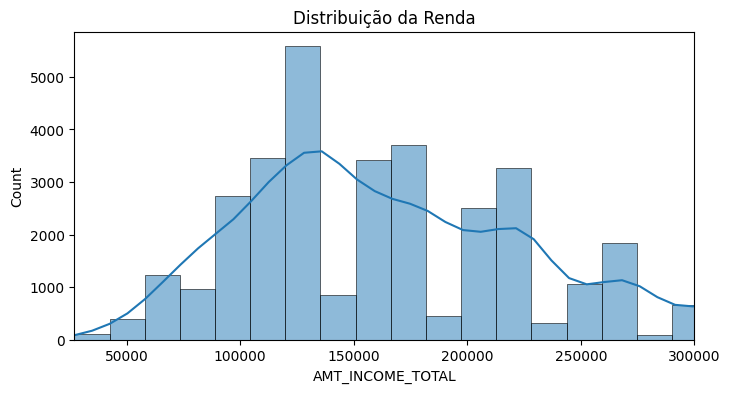

In [195]:
#Histograma para AMT_INCOME_TOTAL.

plt.figure(figsize=(8,4))
sns.histplot(df_final["AMT_INCOME_TOTAL"], kde=True, bins=100)
plt.title("Distribuição da Renda")
plt.xlim(27000, 300000)
plt.show()

O histograma da **Distribuição da Renda (AMT_INCOME_TOTAL)** mostra uma concentração de indivíduos nas faixas de renda mais baixas e médias. Há picos notáveis em torno de 120.000 e 180.000, e a distribuição tende a ser assimétrica positiva (cauda longa à direita), indicando a presença de algumas rendas mais elevadas.

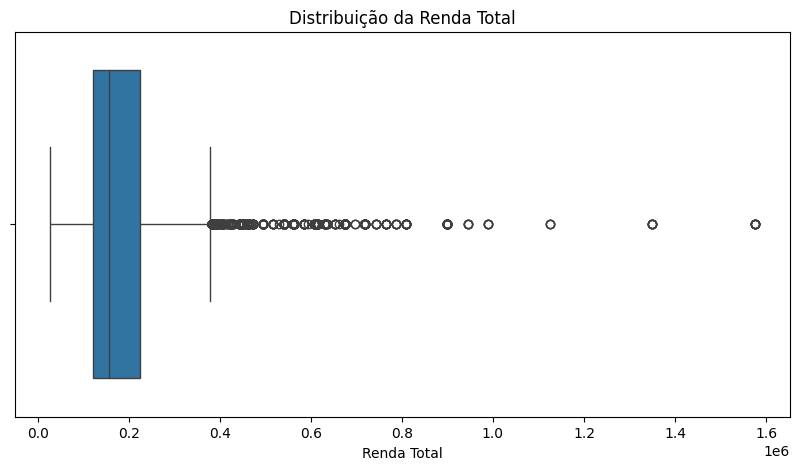

In [196]:
#Boxplot para AMT_INCOME_TOTAL.

plt.figure(figsize=(10, 5))
sns.boxplot(x=df_final["AMT_INCOME_TOTAL"])
plt.title("Distribuição da Renda Total")
plt.xlabel("Renda Total")
plt.show()

O *boxplot* da **Distribuição da Renda Total (AMT_INCOME_TOTAL)** corrobora a assimetria observada no histograma, com uma grande concentração de dados na parte inferior da caixa. A presença de vários pontos individuais fora dos 'bigodes' do *boxplot* à direita indica a existência de *outliers*, ou seja, pessoas com rendas significativamente mais altas que a maioria.

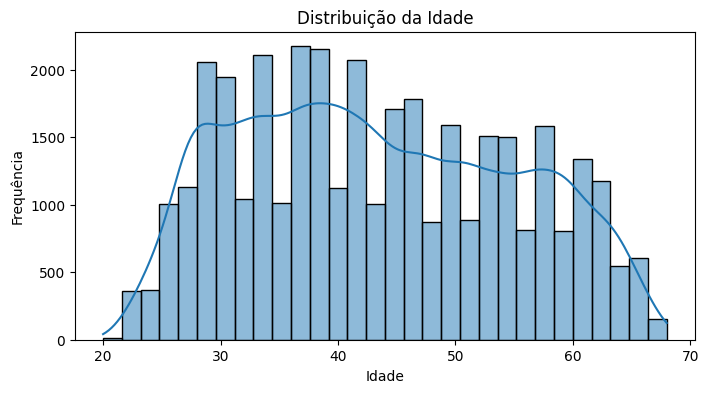

In [197]:
#Histograma para YEARS_BIRTH.
plt.figure(figsize=(8,4))
sns.histplot(df_final["YEARS_BIRTH"], kde=True, bins=30)
plt.title("Distribuição da Idade")
plt.xlabel("Idade")
plt.ylabel("Frequência")
plt.show()

O histograma da **Distribuição da Idade (YEARS_BIRTH)** revela que a maior parte dos solicitantes está na faixa dos 30 a 40 anos, com uma distribuição que se assemelha a uma curva normal, mas com um leve pico em idades mais jovens. Há uma diminuição gradual na frequência conforme a idade avança.

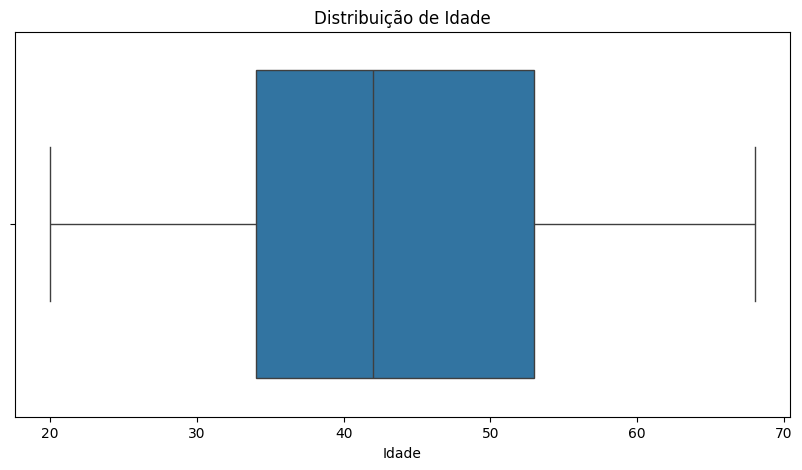

In [198]:
#Boxplot para YEARS_BIRTH

plt.figure(figsize=(10, 5))
sns.boxplot(x=df_final["YEARS_BIRTH"])
plt.title("Distribuição de Idade")
plt.xlabel("Idade")
plt.show()

O *boxplot* da **Distribuição de Idade (YEARS_BIRTH)** mostra que a idade mediana dos solicitantes está em torno de 42 anos. A maior parte dos dados (entre o 1º e 3º quartil) está concentrada entre aproximadamente 34 e 53 anos. Não há *outliers* visíveis neste gráfico, indicando que as idades se mantêm dentro de um intervalo esperado.

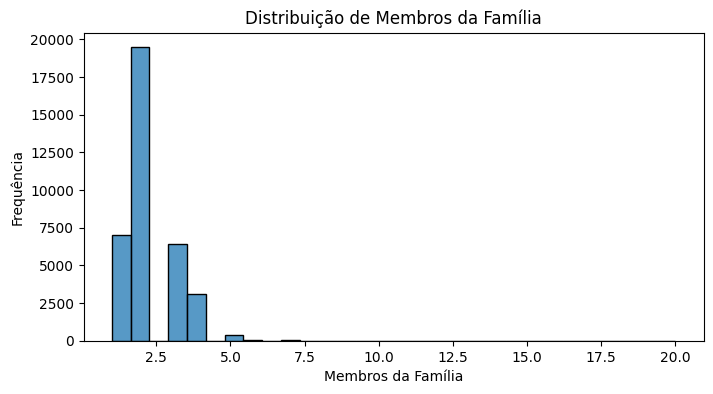

In [199]:
#Histograma para CNT_FAM_MEMBERS.
plt.figure(figsize=(8,4))
sns.histplot(df_final["CNT_FAM_MEMBERS"], bins =30)
plt.title("Distribuição de Membros da Família")
plt.xlabel("Membros da Família")
plt.ylabel("Frequência")
plt.show()

O histograma da **Distribuição de Membros da Família (CNT_FAM_MEMBERS)** indica que a maioria dos solicitantes tem 2 membros na família, seguido por 1 membro e 3 membros. Famílias maiores (com 4 ou mais membros) são menos frequentes. Existem alguns poucos casos de famílias muito grandes, representados como barras pequenas à direita.

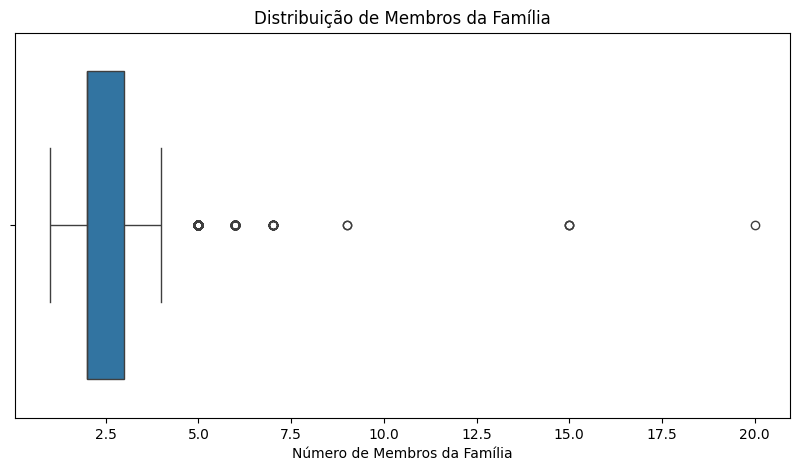

In [200]:
#Boxplot para CNT_FAM_MEMBERS

plt.figure(figsize=(10, 5))
sns.boxplot(x=df_final["CNT_FAM_MEMBERS"])
plt.title("Distribuição de Membros da Família")
plt.xlabel("Número de Membros da Família")
plt.show()

O *boxplot* da **Distribuição de Membros da Família (CNT_FAM_MEMBERS)** confirma que a maioria das famílias tem 2 membros (mediana). A maior parte dos dados está entre 2 e 3 membros. Há alguns *outliers* à direita, representando famílias com um número excepcionalmente alto de membros.

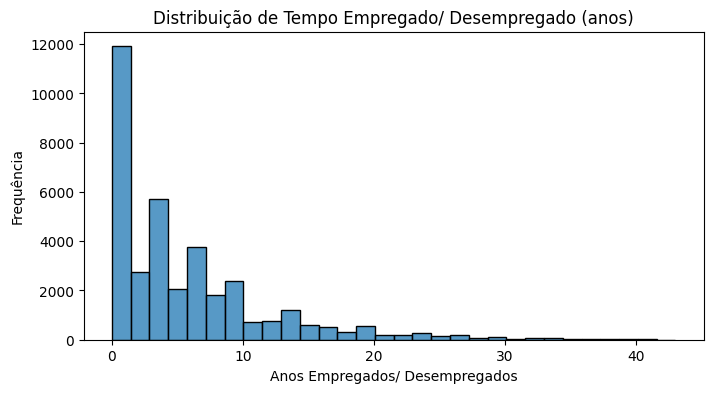

In [201]:
#Histograma para YEARS_EMPLOYED.

plt.figure(figsize=(8,4))
sns.histplot(df_final["YEARS_EMPLOYED"], bins=30)
plt.title("Distribuição de Tempo Empregado/ Desempregado (anos)")
plt.xlabel("Anos Empregados/ Desempregados")
plt.ylabel("Frequência")
plt.show()

O histograma da **Distribuição de Tempo Empregado/Desempregado (YEARS_EMPLOYED)** mostra um pico significativo em 0 anos, que corresponde aos indivíduos inativos/pensionistas que tiveram o valor de -1000 substituído por 0. A partir daí, a distribuição decai rapidamente, indicando que a maioria dos empregados tem poucos anos de serviço, e um número menor de indivíduos possui mais anos de experiência.

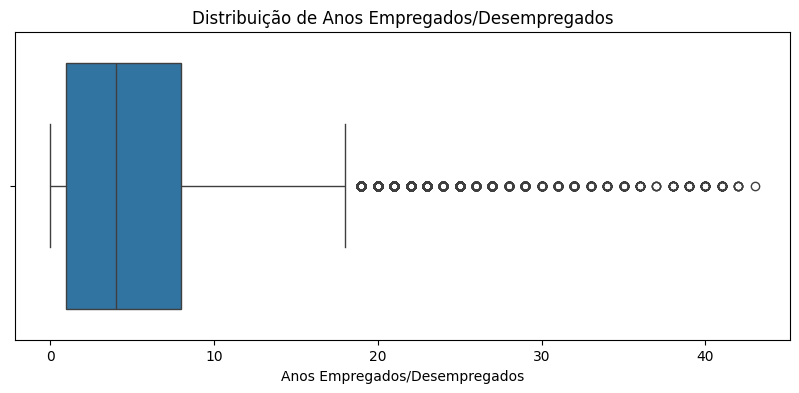

In [202]:
#Boxplot para YEARS_EMPLOYED

plt.figure(figsize=(10,4))
sns.boxplot(x=df_final["YEARS_EMPLOYED"])
plt.title("Distribuição de Anos Empregados/Desempregados")
plt.xlabel("Anos Empregados/Desempregados")
plt.show()

O *boxplot* da **Distribuição de Anos Empregados/Desempregados (YEARS_EMPLOYED)**, após o tratamento do valor -1000 para 0, mostra uma mediana baixa (em torno de 4 anos). A maior parte dos dados (entre o 1º e 3º quartil) está concentrada nos primeiros anos de emprego. Há muitos *outliers* à direita, indicando indivíduos com longos períodos de emprego, o que é esperado, já que alguns têm mais de 40 anos de experiência.

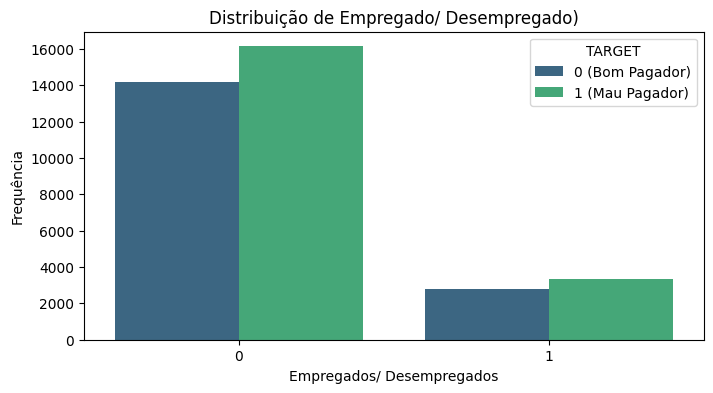

In [203]:
##Distribuição para IS_INACTIVE

plt.figure(figsize=(8,4))

sns.countplot(
    data=df_final,
    x="IS_INACTIVE",
    hue="TARGET",
    order=df_final["IS_INACTIVE"].value_counts().index,
    palette="viridis",
)

plt.title("Distribuição de Empregado/ Desempregado)")
plt.xlabel("Empregados/ Desempregados")
plt.ylabel("Frequência")

plt.legend(
    title="TARGET",
    labels=["0 (Bom Pagador)", "1 (Mau Pagador)"],
    loc="upper right",
)

plt.show()




O gráfico da **Distribuição de Empregado/Desempregado (IS_INACTIVE)** mostra claramente que a maioria dos solicitantes está ativa (0), enquanto uma parcela menor é inativa (1), confirmando a proporção de pensionistas/inativos identificada anteriormente.

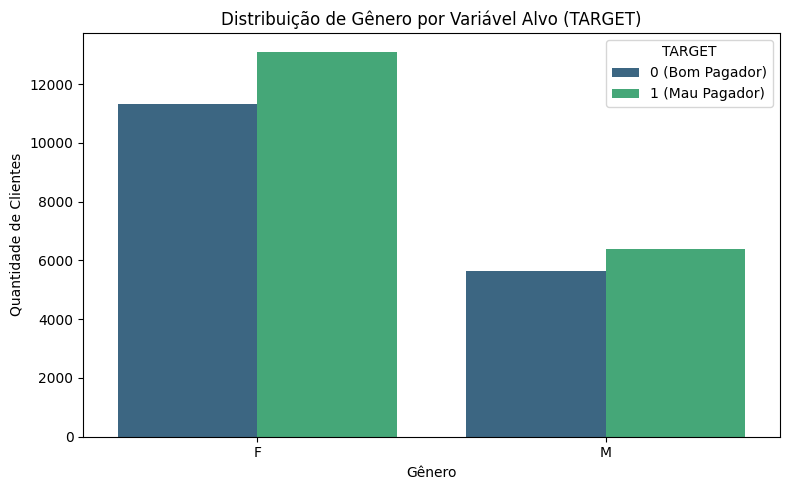

In [204]:
#Distribuição para CODE_GENDER

plt.figure(figsize=(8, 5))

# Adicionamos hue="TARGET" para separar as barras por classe (0 e 1)
sns.countplot(
    data=df_final,
    x="CODE_GENDER",
    hue="TARGET",
    order=df_final["CODE_GENDER"].value_counts().index,
    palette="viridis",
)

plt.title("Distribuição de Gênero por Variável Alvo (TARGET)", fontsize=12)
plt.xlabel("Gênero", fontsize=10)
plt.ylabel("Quantidade de Clientes", fontsize=10)

# Ajusta a legenda para indicar o significado dos valores
plt.legend(
    title="TARGET",
    labels=["0 (Bom Pagador)", "1 (Mau Pagador)"],
    loc="upper right",
)

plt.tight_layout()
plt.show()


O gráfico da **Distribuição por Gênero (CODE_GENDER)** indica que a base de dados possui significativamente mais mulheres ('F') do que homens ('M').

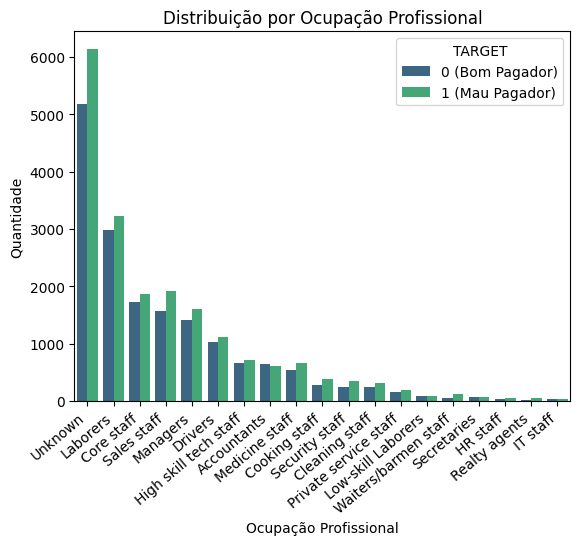

In [205]:
#Distribuição para OCCUPATION_TYPE.


sns.countplot(
    data=df_final,
    x="OCCUPATION_TYPE",
    hue="TARGET",
    order=df_final["OCCUPATION_TYPE"].value_counts().index,
    palette="viridis",
)

# sns.countplot(data=df_final, x="OCCUPATION_TYPE", order=df_final["OCCUPATION_TYPE"].value_counts().index, palette='viridis')

plt.title("Distribuição por Ocupação Profissional")
plt.xlabel("Ocupação Profissional")
plt.xticks(rotation=40, ha="right")
plt.ylabel("Quantidade")

plt.legend(
    title="TARGET",
    labels=["0 (Bom Pagador)", "1 (Mau Pagador)"],
    loc="upper right",
)

plt.show()


O gráfico da **Distribuição por Ocupação Profissional (OCCUPATION_TYPE)** destaca que a categoria 'Unknown' (desconhecido, que preenche os valores nulos) é a mais frequente, seguida por 'Laborers' e 'Core staff'. Isso sugere que há muitos dados de ocupação ausentes ou não especificados.

/tmp/ipykernel_2923/3317911779.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final, x="NAME_INCOME_TYPE", order=df_final["NAME_INCOME_TYPE"].value_counts().index, palette="viridis")


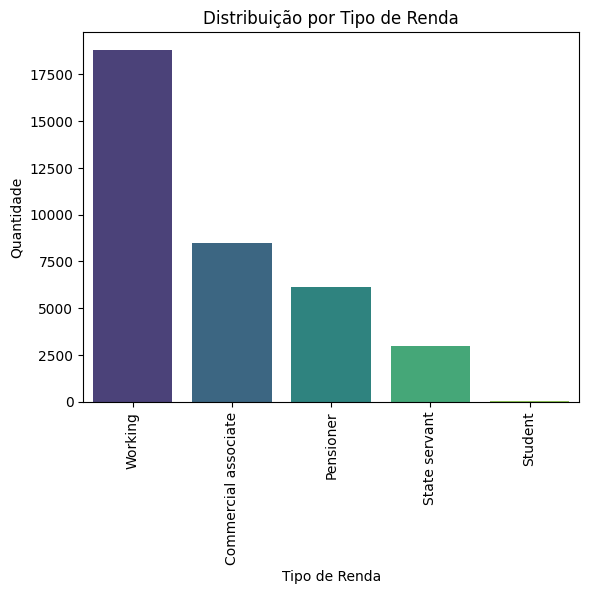

In [206]:
#Distribuição para NAME_INCOME_TYPE.

sns.countplot(data=df_final, x="NAME_INCOME_TYPE", order=df_final["NAME_INCOME_TYPE"].value_counts().index, palette="viridis")
plt.title("Distribuição por Tipo de Renda")
plt.xlabel("Tipo de Renda")
plt.xticks(rotation=90)
plt.ylabel("Quantidade")
plt.show()

A **Distribuição por Tipo de Renda (NAME_INCOME_TYPE)** mostra que a categoria 'Working' (trabalhadores ativos) é a mais predominante, seguida por 'Commercial associate' e 'Pensioner'. Isso reflete a composição da base de dados, com a maioria dos indivíduos tendo renda advinda de trabalho formal.

/tmp/ipykernel_2923/1614703125.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final, x="FLAG_OWN_CAR", order=df_final["FLAG_OWN_CAR"].value_counts().index, palette="viridis")


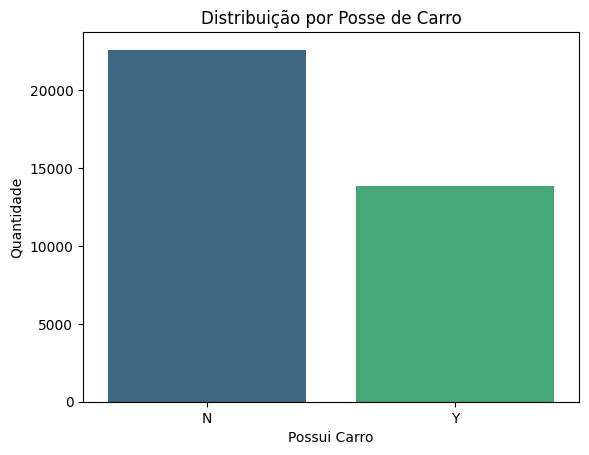

In [207]:
#Distribuição para FLAG_OWN_CAR.

sns.countplot(data=df_final, x="FLAG_OWN_CAR", order=df_final["FLAG_OWN_CAR"].value_counts().index, palette="viridis")
plt.title("Distribuição por Posse de Carro")
plt.xlabel("Possui Carro")
plt.ylabel("Quantidade")
plt.show()

O gráfico da **Distribuição por Posse de Carro (FLAG_OWN_CAR)** indica que a maioria dos solicitantes não possui carro ('N'), enquanto uma parte menor possui ('Y').

/tmp/ipykernel_2923/4159014428.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final, x="FLAG_OWN_REALTY", order=df_final["FLAG_OWN_REALTY"].value_counts().index, palette="viridis")


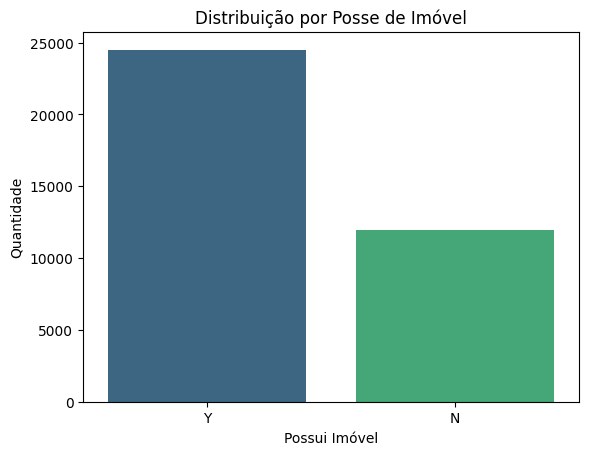

In [208]:
#Distribuição para FLAG_OWN_REALTY.

sns.countplot(data=df_final, x="FLAG_OWN_REALTY", order=df_final["FLAG_OWN_REALTY"].value_counts().index, palette="viridis")
plt.title("Distribuição por Posse de Imóvel")
plt.xlabel("Possui Imóvel")
plt.ylabel("Quantidade")
plt.show()

A **Distribuição por Posse de Imóvel (FLAG_OWN_REALTY)** mostra que a maioria dos indivíduos possui imóvel ('Y'), superando aqueles que não possuem ('N').

/tmp/ipykernel_2923/145525068.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final, x="NAME_EDUCATION_TYPE", order=df_final["NAME_EDUCATION_TYPE"].value_counts().index, palette="viridis")


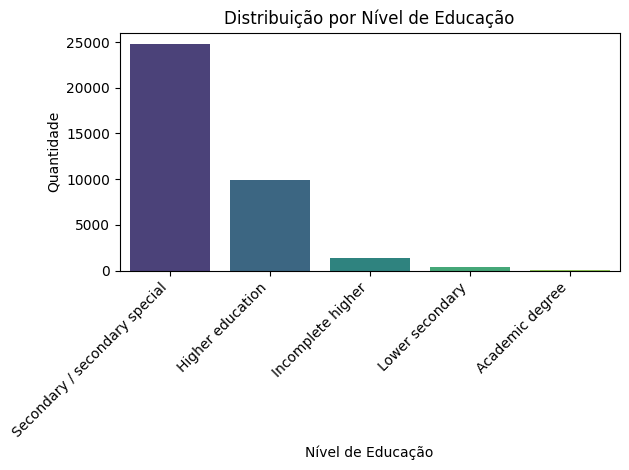

In [209]:
#Distribuição para NAME_EDUCATION_TYPE.
sns.countplot(data=df_final, x="NAME_EDUCATION_TYPE", order=df_final["NAME_EDUCATION_TYPE"].value_counts().index, palette="viridis")
plt.title("Distribuição por Nível de Educação")
plt.xlabel("Nível de Educação")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

O gráfico da **Distribuição por Nível de Educação (NAME_EDUCATION_TYPE)** evidencia que a maior parte dos solicitantes possui 'Secondary / secondary special' (ensino médio/técnico), seguido por 'Higher education' (ensino superior). Os demais níveis de escolaridade têm representação bem menor.

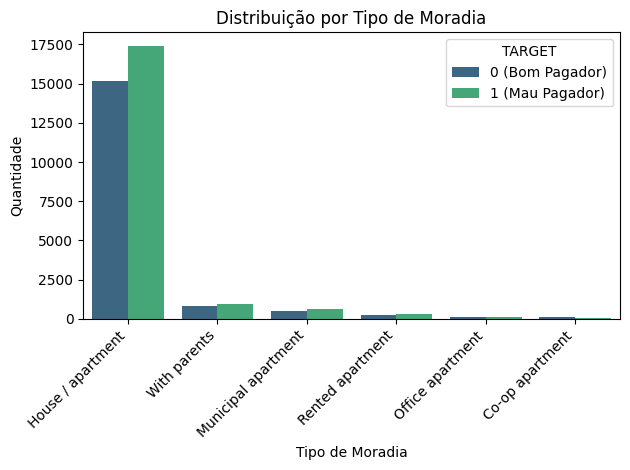

In [210]:
#Distribuição para NAME_HOUSING_TYPE.

sns.countplot(
    data=df_final,
    x="NAME_HOUSING_TYPE",
    hue="TARGET",
    order=df_final["NAME_HOUSING_TYPE"].value_counts().index,
    palette="viridis",
)

# sns.countplot(data=df_final, x="NAME_HOUSING_TYPE", order=df_final["NAME_HOUSING_TYPE"].value_counts().index, palette="viridis")
plt.title("Distribuição por Tipo de Moradia")
plt.xlabel("Tipo de Moradia")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Quantidade")

plt.legend(
    title="TARGET",
    labels=["0 (Bom Pagador)", "1 (Mau Pagador)"],
    loc="upper right",
)
plt.tight_layout()
plt.show()

O gráfico da **Distribuição por Tipo de Moradia (NAME_HOUSING_TYPE)** aponta que 'House / apartment' (casa/apartamento) é o tipo de moradia esmagadoramente dominante entre os solicitantes, com outros tipos como 'With parents' ou 'Municipal apartment' sendo muito menos comuns.

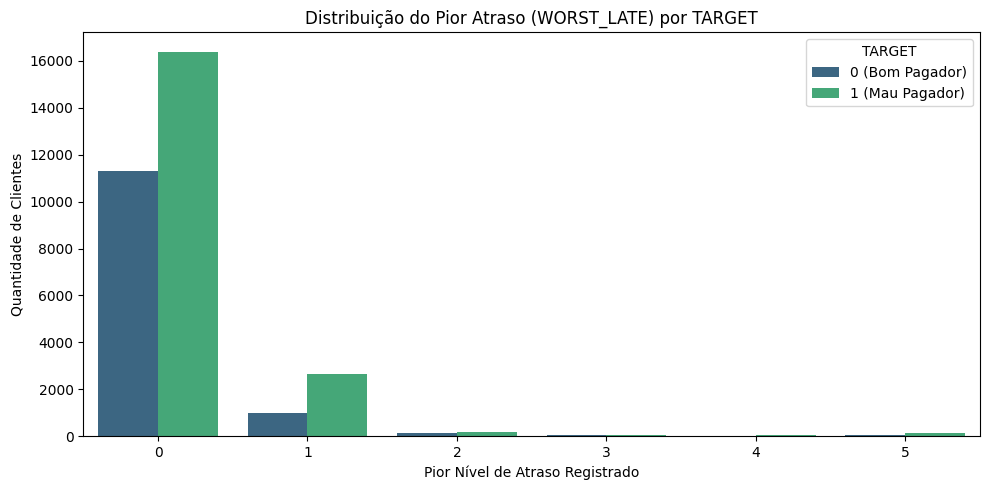

In [211]:
#Histograma para STATUS_LATED.
# plt.figure(figsize=(8,4))
# sns.histplot(df_final["WORST_LATE"])
# plt.title('Distribuição do Pior Atraso por Cliente')
# plt.xlabel('Quantidade Pior Atraso')
# plt.ylabel('Frequência')
# plt.show()

import matplotlib.pyplot as plt
import seaborn as sns

# Ordem lógica dos status de atraso
order_worst = ["0", "1", "2", "3", "4", "5"]

plt.figure(figsize=(10, 5))

# Opção com countplot (mais recomendada para categóricos)
sns.countplot(
    data=df_final,
    x="WORST_LATE",
    hue="TARGET",
    order=[c for c in order_worst if c in df_final["WORST_LATE"].unique()],
    palette="viridis",
)

plt.title("Distribuição do Pior Atraso (WORST_LATE) por TARGET", fontsize=12)
plt.xlabel("Pior Nível de Atraso Registrado", fontsize=10)
plt.ylabel("Quantidade de Clientes", fontsize=10)

plt.legend(
    title="TARGET",
    labels=["0 (Bom Pagador)", "1 (Mau Pagador)"],
    loc="upper right",
)

plt.tight_layout()
plt.show()

O histograma da **Distribuição do Pior Atraso (WORST_LATE)** revela que a grande maioria dos clientes possui um número baixo de atrasos (entre 1 e 5). Há uma concentração no valor 0, indicando muitos clientes com atrasos de 1 mês apenas. Conforme o número de atrasos aumenta, a frequência diminui drasticamente, mostrando que poucos clientes acumulam muitos atrasos.

/tmp/ipykernel_2923/2708736565.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2923/2708736565.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


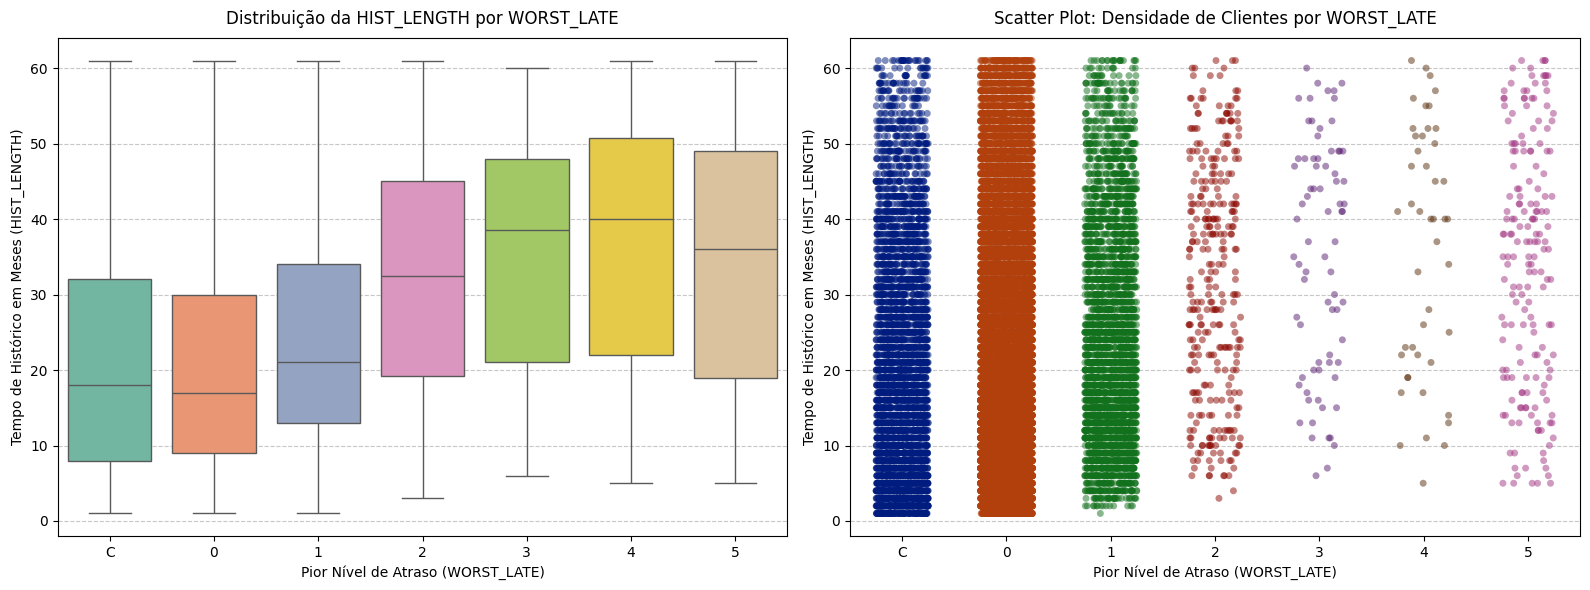

In [212]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Definir a ordem correta das categorias do pior atraso no eixo X
order_worst = ["X", "C", "0", "1", "2", "3", "4", "5"]
labels_worst = [
    "X\n(Sem Crédito)",
    "C\n(Em Dia)",
    "0\n(1-29d)",
    "1\n(30-59d)",
    "2\n(60-89d)",
    "3\n(90-119d)",
    "4\n(120-149d)",
    "5\n(150d+)",
]

# Configurar a figura com 2 subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -------------------------------------------------------------------------
# Gráfico 1: Boxplot da Distribuição de HIST_LENGTH por WORST_LATE
# -------------------------------------------------------------------------
sns.boxplot(
    data=df_final,
    x="WORST_LATE",
    y="HIST_LENGTH",
    order=[c for c in order_worst if c in df_final["WORST_LATE"].unique()],
    palette="Set2",
    ax=axes[0],
)

axes[0].set_title(
    "Distribuição da HIST_LENGTH por WORST_LATE", fontsize=12, pad=10
)
axes[0].set_xlabel("Pior Nível de Atraso (WORST_LATE)", fontsize=10)
axes[0].set_ylabel("Tempo de Histórico em Meses (HIST_LENGTH)", fontsize=10)
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

# -------------------------------------------------------------------------
# Gráfico 2: Scatterplot Categórico (Strip Plot com Jitter)
# -------------------------------------------------------------------------
sns.stripplot(
    data=df_final,
    x="WORST_LATE",
    y="HIST_LENGTH",
    order=[c for c in order_worst if c in df_final["WORST_LATE"].unique()],
    jitter=0.25,  # Espalha os pontos para evitar sobreposição
    alpha=0.5,  # Transparência dos pontos
    size=5,
    palette="dark",
    ax=axes[1],
)

axes[1].set_title(
    "Scatter Plot: Densidade de Clientes por WORST_LATE", fontsize=12, pad=10
)
axes[1].set_xlabel("Pior Nível de Atraso (WORST_LATE)", fontsize=10)
axes[1].set_ylabel("Tempo de Histórico em Meses (HIST_LENGTH)", fontsize=10)
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

A análise bivariada entre o tempo de histórico (`HIST_LENGTH`) e o pior status de atraso (`WORST_LATE`) indica que clientes com histórico mais longo têm maior oportunidade de apresentar algum atraso. Por isso, a interpretação deve considerar também a taxa normalizada `LATE_RATE`, as janelas `LATE_3M`, `LATE_6M`, `LATE_9M` e `LATE_12M`, além da recência `LAST_LATE`. A gravidade de `WORST_LATE` não deve ser confundida com a quantidade de meses em atraso: são dimensões diferentes do comportamento de crédito.

## 3. Correlações

**Interpretação:** _comente cada correlação relevante, uma a uma._

In [213]:
#Preparar DataFrame para a matriz de correlação
df_corr = df_final.copy()

# Mapear variáveis categóricas binárias para numéricas.
df_corr["CODE_GENDER"] = df_corr["CODE_GENDER"].map({"M": 1, "F": 0})
df_corr["FLAG_OWN_CAR"] = df_corr["FLAG_OWN_CAR"].map({"Y": 1, "N": 0})
df_corr["FLAG_OWN_REALTY"] = df_corr["FLAG_OWN_REALTY"].map({"Y": 1, "N": 0})
df_corr["WORST_LATE"] = df_corr["WORST_LATE"].map({"C": 0, "0": 1, "1": 2, "2": 3, "3": 4, "4": 5, "5": 6})
df_corr["TARGET"] = pd.to_numeric(df_corr["TARGET"], errors="coerce")

# Identificar colunas categóricas restantes que não são binárias
categorical_cols_to_encode = [
    'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE'
]

# Aplicar One-Hot Encoding para as variáveis categóricas restantes
df_encoded_cols = pd.get_dummies(df_corr[categorical_cols_to_encode], prefix=categorical_cols_to_encode)

# Juntar as colunas codificadas ao df_corr e remover as colunas originais
df_corr = pd.concat([df_corr.drop(columns=categorical_cols_to_encode), df_encoded_cols], axis=1)

# Selecionar as colunas numéricas para a matriz de correlação, incluindo as que foram mapeadas para numéricas
# e as novas variáveis do histórico de crédito, a variável alvo e as recém-codificadas.
numerical_cols = [
    "CODE_GENDER", "FLAG_OWN_CAR", "FLAG_OWN_REALTY", "CNT_CHILDREN",
    "AMT_INCOME_TOTAL","YEARS_BIRTH", "YEARS_EMPLOYED", "IS_INACTIVE",
    "CNT_FAM_MEMBERS", "FLAG_WORK_PHONE", "FLAG_PHONE", "FLAG_EMAIL",
    "LATE_3M", "LATE_6M", "LATE_9M", "LATE_12M", "WORST_LATE", "LAST_LATE",
    "HIST_LENGTH", "TOTAL_LATES", "LATE_RATE", "TARGET"
] + list(df_encoded_cols.columns)

# Filtrar df_corr para incluir apenas as colunas numéricas selecionadas
df_numerical_corr = df_corr[numerical_cols]

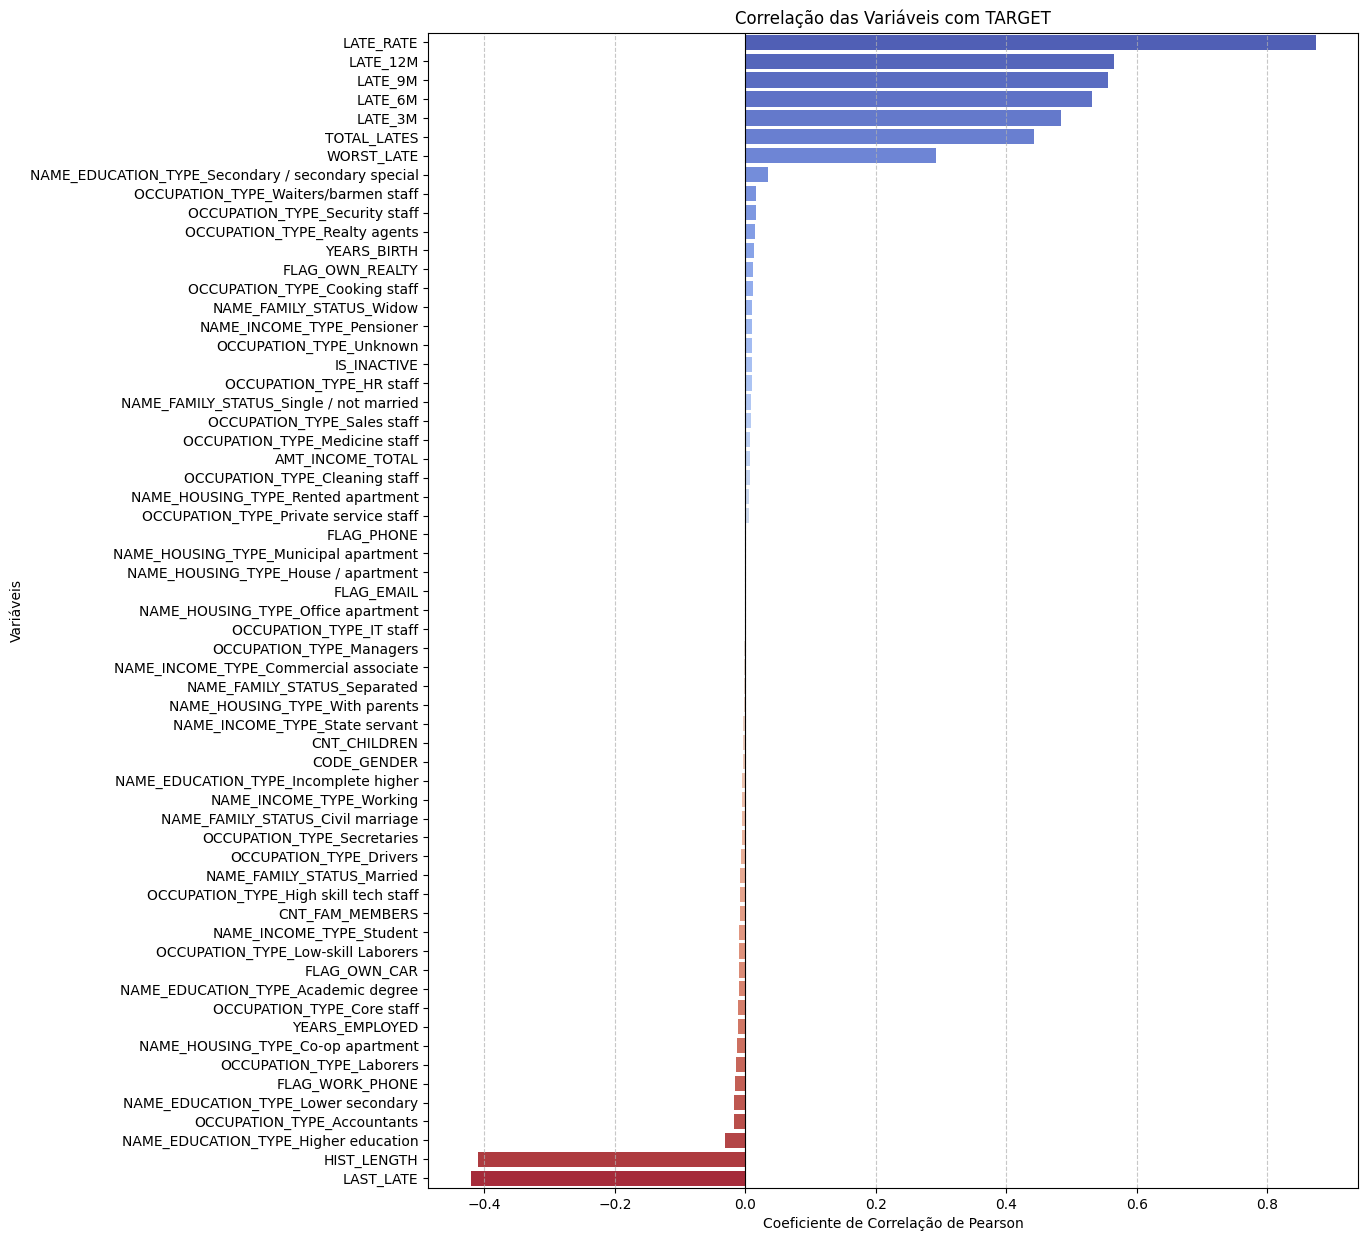

In [220]:
# Calcular a correlação de todas as variáveis numéricas com TARGET.
correlations_with_target = (
    df_numerical_corr.corrwith(df_numerical_corr["TARGET"])
    .drop("TARGET")
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 15))
sns.barplot(
    x=correlations_with_target.values,
    y=correlations_with_target.index,
    hue=correlations_with_target.index,
    palette="coolwarm",
    legend=False,
)
plt.title("Correlação das Variáveis com TARGET")
plt.xlabel("Coeficiente de Correlação de Pearson")
plt.ylabel("Variáveis")
plt.axvline(0, color="black", linewidth=0.8)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

Gerado o gráfico de barras para conter todas as variáveis e visualizar as correlações com a variável "TARGET". Pode-se observar que 'LATE_RATE" tem a correlação mais forte, seguido pelas variáveis de gravidade de atraso, começando pela mais grave ("LATE_12M") e seguindo para as menos agravantes em ordem decrescente ("LATE_9M", "LATE_6M" e assim por diante).  

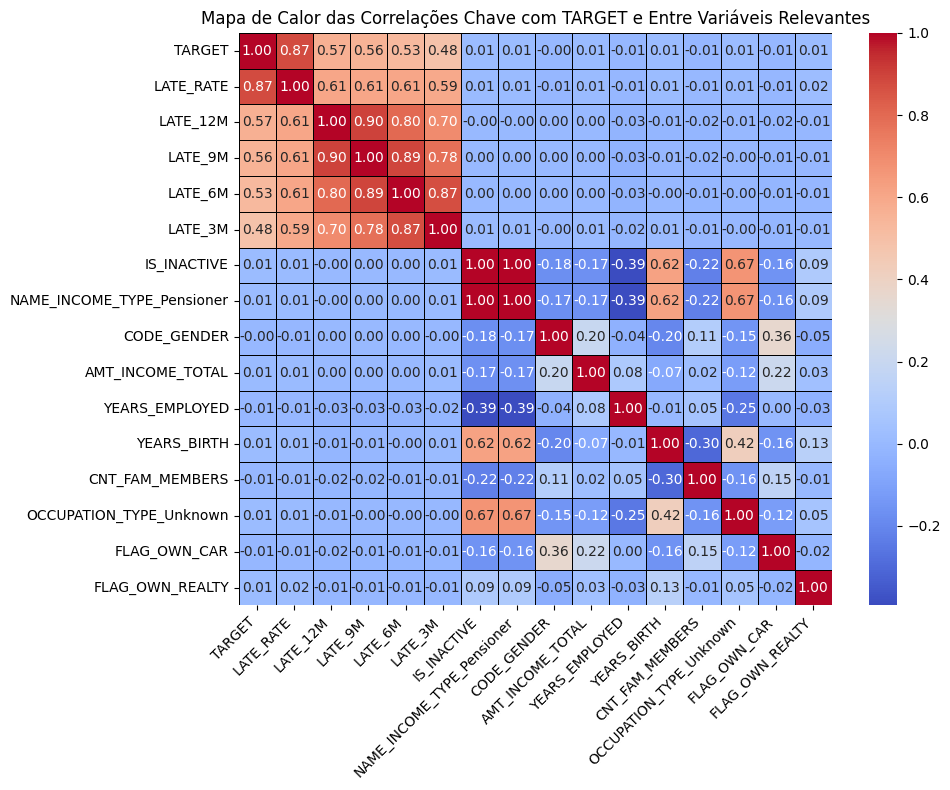

In [215]:
# Colunas relevantes para a criação da matriz de correlação.
relevant_cols = [
    'TARGET', #Variável alvo
    'LATE_RATE',
    'LATE_12M',
    'LATE_9M',
    'LATE_6M',
    'LATE_3M',
    'IS_INACTIVE',
    'NAME_INCOME_TYPE_Pensioner',
    'CODE_GENDER',
    'AMT_INCOME_TOTAL',
    'YEARS_EMPLOYED',
    'YEARS_BIRTH',
    'CNT_FAM_MEMBERS',
    'OCCUPATION_TYPE_Unknown',
    'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY'
]

# Calcular a matriz de correlação para as variáveis selecionadas
correlation_matrix = df_numerical_corr[relevant_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, linecolor='black')
plt.title('Mapa de Calor das Correlações Chave com TARGET e Entre Variáveis Relevantes')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

A análise de Pearson relaciona cada variável numérica com `TARGET`, em que `1` representa mau pagador e `0` representa bom pagador. Correlação não implica causalidade e, no caso de variáveis de atraso, parte da associação é esperada porque o próprio `TARGET` foi definido a partir do comportamento histórico de crédito.

**Associações positivas:**

* `LATE_RATE`, `TOTAL_LATES` e `WORST_LATE` tendem a apresentar as associações positivas mais fortes. Quanto maior a frequência, a quantidade ou a gravidade dos atrasos, maior a tendência de `TARGET = 1`.
* `LATE_3M`, `LATE_6M`, `LATE_9M` e `LATE_12M` representam a ocorrência de atraso em diferentes janelas. As janelas mais recentes ajudam a capturar risco atual; as mais longas capturam persistência do comportamento.
* `LAST_LATE` deve ser interpretada com cautela: valores menores significam atraso mais recente. Por isso, sua associação pode ser negativa mesmo quando a recência é importante para o risco.

**Associações negativas ou fracas:**

* `IS_INACTIVE` e `NAME_INCOME_TYPE_Pensioner` podem apresentar associação negativa ou próxima de zero, indicando pouca evidência de relação linear com a inadimplência nesta amostra.
* `AMT_INCOME_TOTAL`, `YEARS_BIRTH`, `YEARS_EMPLOYED`, `CNT_FAM_MEMBERS`, `CODE_GENDER`, `FLAG_OWN_CAR` e `FLAG_OWN_REALTY` tendem a ter correlações menores. Isso não significa que sejam inúteis, apenas que não demonstram relação linear forte isoladamente.

A lista abaixo do gráfico ordena as correlações; portanto, os maiores valores positivos ficam no topo e os menores, incluindo os negativos, ficam na parte inferior. A decisão de modelagem deve considerar também métricas, validação e possíveis relações não lineares.

## 4. Outliers

**Interpretação:** _remover, winsorizar ou manter? Justifique._

In [216]:
# Identificar outliers apenas em variáveis contínuas ou de contagem.
# IDs, flags, categorias ordinais e TARGET não devem ser avaliados pelo IQR.
outlier_cols = [
    "CNT_CHILDREN",
    "AMT_INCOME_TOTAL",
    "CNT_FAM_MEMBERS",
    "YEARS_BIRTH",
    "YEARS_EMPLOYED",
    "LAST_LATE",
    "HIST_LENGTH",
    "TOTAL_LATES",
    "LATE_RATE",
]

print("Análise de outliers para as seguintes colunas:", outlier_cols)
print("\n" + "-" * 50 + "\n")

outlier_summary = {}

for col in outlier_cols:
    q1 = df_final[col].quantile(0.25)
    q3 = df_final[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_mask = (df_final[col] < lower_bound) | (df_final[col] > upper_bound)
    num_outliers = int(outlier_mask.sum())
    percentage_outliers = num_outliers / len(df_final) * 100

    outlier_summary[col] = {
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Number of Outliers": num_outliers,
        "Percentage of Outliers": percentage_outliers,
    }

    print(f"Variável: {col}")
    print(f"  Limites IQR: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"  Número de outliers: {num_outliers}")
    print(f"  Proporção de outliers: {percentage_outliers:.2f}%")
    print("\n" + "-" * 50 + "\n")

Análise de outliers para as seguintes colunas: ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'CNT_FAM_MEMBERS', 'YEARS_BIRTH', 'YEARS_EMPLOYED', 'LAST_LATE', 'HIST_LENGTH', 'TOTAL_LATES', 'LATE_RATE']

--------------------------------------------------

Variável: CNT_CHILDREN
  Limites IQR: [-1.50, 2.50]
  Número de outliers: 508
  Proporção de outliers: 1.39%

--------------------------------------------------

Variável: AMT_INCOME_TOTAL
  Limites IQR: [-33750.00, 380250.00]
  Número de outliers: 1529
  Proporção de outliers: 4.19%

--------------------------------------------------

Variável: CNT_FAM_MEMBERS
  Limites IQR: [0.50, 4.50]
  Número de outliers: 480
  Proporção de outliers: 1.32%

--------------------------------------------------

Variável: YEARS_BIRTH
  Limites IQR: [5.50, 81.50]
  Número de outliers: 0
  Proporção de outliers: 0.00%

--------------------------------------------------

Variável: YEARS_EMPLOYED
  Limites IQR: [-9.50, 18.50]
  Número de outliers: 1999
  Proporção 

As variáveis de comportamento de crédito (`LATE_3M`, `LATE_6M`, `LATE_9M`, `LATE_12M`, `WORST_LATE`, `LAST_LATE`, `TOTAL_LATES` e `LATE_RATE`) não serão removidas automaticamente como outliers. Valores altos ou recentes nessas variáveis representam justamente perfis de maior risco. Além disso, `WORST_LATE` é ordinal e as flags `LATE_*` são binárias, portanto a regra do IQR não é adequada para elas.

Para as variáveis contínuas e de contagem, a análise do IQR serve para diagnosticar valores extremos. O tratamento será seletivo: `CNT_CHILDREN` e `CNT_FAM_MEMBERS` podem usar capping por representarem contagens com poucos valores extremos; `AMT_INCOME_TOTAL` será representada também por `AMT_INCOME_TOTAL_LOG`; e as variáveis de histórico serão preservadas para não apagar informação de risco.

### Tratamento seletivo de outliers em contagens

Conforme a análise pelo IQR, `CNT_CHILDREN` e `CNT_FAM_MEMBERS` podem conter valores extremos isolados. Aplicaremos capping somente nessas duas variáveis, limitando os valores aos limites inferior e superior do IQR. Essa decisão reduz a influência de famílias muito grandes sem eliminar registros e sem alterar as variáveis de comportamento de crédito, que carregam informação importante para o risco.

Estatísticas descritivas de CNT_CHILDREN após o capping:


count    36457.000000
mean         0.418959
std          0.688709
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          2.500000
Name: CNT_CHILDREN, dtype: float64

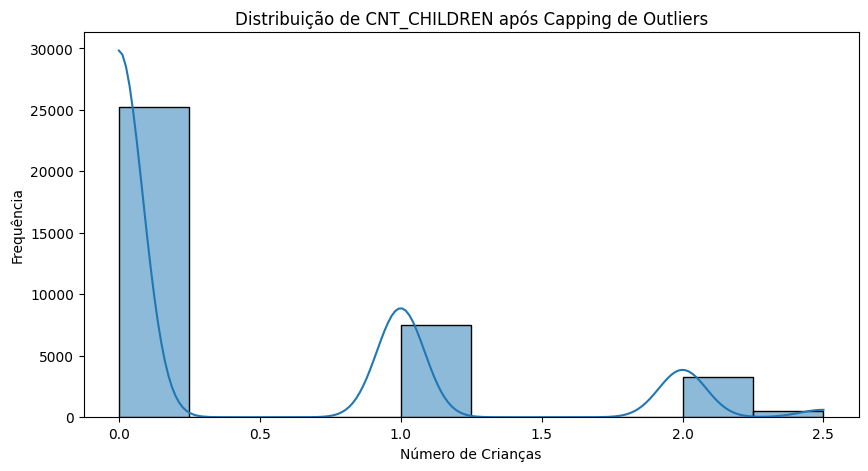

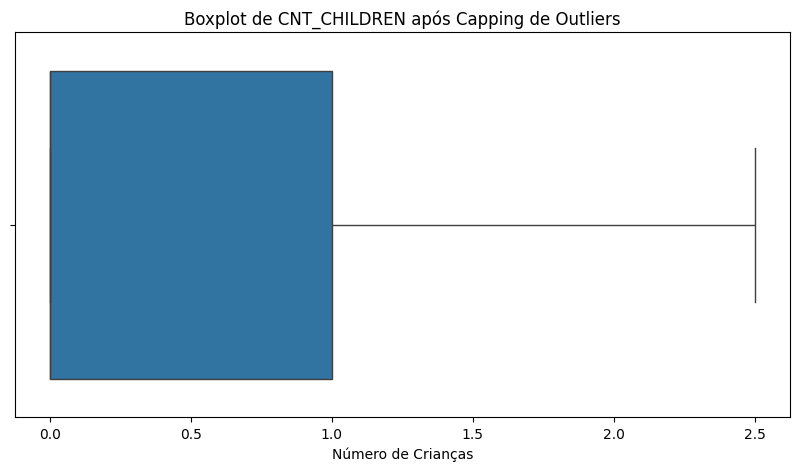

In [217]:
# Aplicar capping para CNT_CHILDREN
lower_bound_children = outlier_summary['CNT_CHILDREN']['Lower Bound']
upper_bound_children = outlier_summary['CNT_CHILDREN']['Upper Bound']

df_final['CNT_CHILDREN'] = np.where(
    df_final['CNT_CHILDREN'] < lower_bound_children, lower_bound_children,
    np.where(df_final['CNT_CHILDREN'] > upper_bound_children, upper_bound_children,
             df_final['CNT_CHILDREN']
    )
)

print("Estatísticas descritivas de CNT_CHILDREN após o capping:")
display(df_final['CNT_CHILDREN'].describe())

# Visualizar a distribuição após o tratamento
plt.figure(figsize=(10, 5))
sns.histplot(df_final['CNT_CHILDREN'], bins=10, kde=True)
plt.title('Distribuição de CNT_CHILDREN após Capping de Outliers')
plt.xlabel('Número de Crianças')
plt.ylabel('Frequência')
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x=df_final['CNT_CHILDREN'])
plt.title('Boxplot de CNT_CHILDREN após Capping de Outliers')
plt.xlabel('Número de Crianças')
plt.show()

Com o capping aplicado, a variável CNT_CHILDREN agora tem seus valores extremos limitados. O histograma e o boxplot mostram uma distribuição mais concentrada, eliminando os outliers que estavam muito além dos limites do IQR. Isso torna a variável mais robusta para análises e modelagens subsequentes.


Estatísticas descritivas de CNT_FAM_MEMBERS após o capping:


count    36457.000000
mean         2.187783
std          0.869257
min          1.000000
25%          2.000000
50%          2.000000
75%          3.000000
max          4.500000
Name: CNT_FAM_MEMBERS, dtype: float64

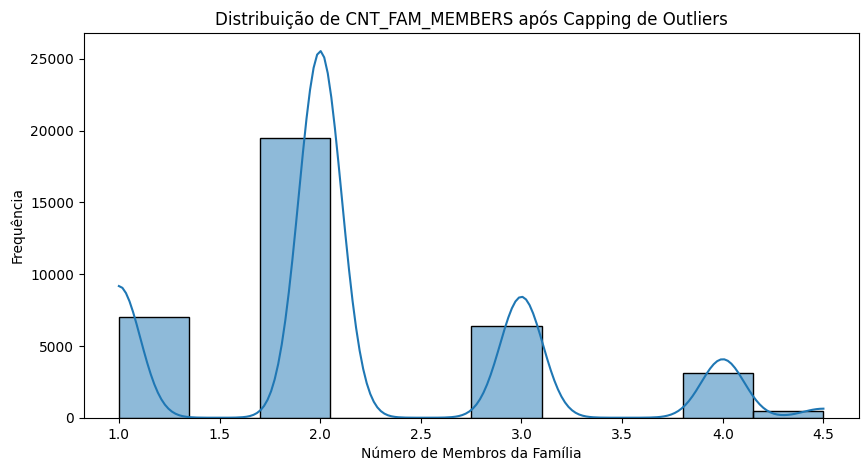

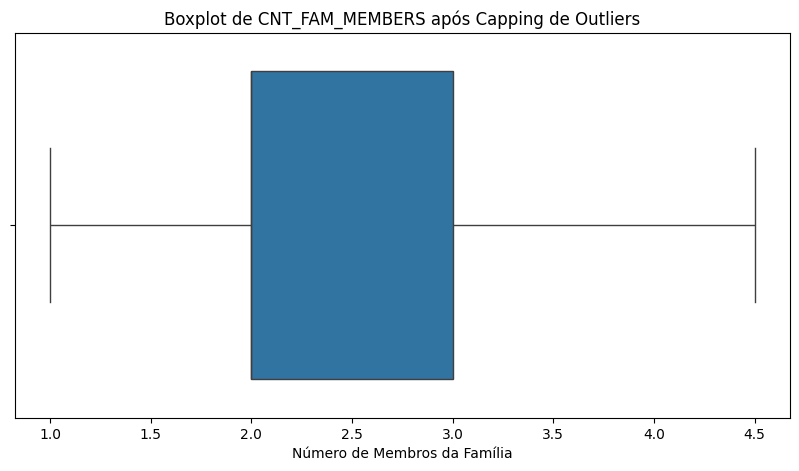

In [218]:
# Aplicar capping para CNT_FAM_MEMBERS
lower_bound_fam = outlier_summary['CNT_FAM_MEMBERS']['Lower Bound']
upper_bound_fam = outlier_summary['CNT_FAM_MEMBERS']['Upper Bound']

df_final['CNT_FAM_MEMBERS'] = np.where(
    df_final['CNT_FAM_MEMBERS'] < lower_bound_fam, lower_bound_fam,
    np.where(df_final['CNT_FAM_MEMBERS'] > upper_bound_fam, upper_bound_fam,
             df_final['CNT_FAM_MEMBERS']
    )
)

print("Estatísticas descritivas de CNT_FAM_MEMBERS após o capping:")
display(df_final['CNT_FAM_MEMBERS'].describe())

# Visualizar a distribuição após o tratamento
plt.figure(figsize=(10, 5))
sns.histplot(df_final['CNT_FAM_MEMBERS'], bins=10, kde=True)
plt.title('Distribuição de CNT_FAM_MEMBERS após Capping de Outliers')
plt.xlabel('Número de Membros da Família')
plt.ylabel('Frequência')
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x=df_final['CNT_FAM_MEMBERS'])
plt.title('Boxplot de CNT_FAM_MEMBERS após Capping de Outliers')
plt.xlabel('Número de Membros da Família')
plt.show()

Os outliers da variável CNT_FAM_MEMBERS foram tratados. As visualizações confirmam que os valores agora se encontram dentro dos limites definidos pelo IQR, o que contribui para uma melhor representação da população e um desempenho mais estável em modelos de Machine Learning. Ambas as variáveis estão agora mais limpas e preparadas para as próximas etapas.

Tratamento de AMT_INCOME_TOTAL com Transformação Logarítmica.
A variável AMT_INCOME_TOTAL possui uma distribuição assimétrica à direita (cauda longa à direita), com a presença de outliers de alta renda. Para tornar essa distribuição mais próxima de uma normal e reduzir a influência desses valores extremos em modelos de Machine Learning, aplicaremos uma transformação logarítmica (np.log1p). Esta transformação é especialmente útil para dados que são estritamente positivos e que exibem uma grande variação, comprimindo os valores maiores e expandindo os menores.

Estatísticas descritivas de AMT_INCOME_TOTAL_LOG após transformação logarítmica:


count    36457.000000
mean        12.018808
std          0.480501
min         10.203629
25%         11.707678
50%         11.967187
75%         12.323860
max         14.269766
Name: AMT_INCOME_TOTAL_LOG, dtype: float64

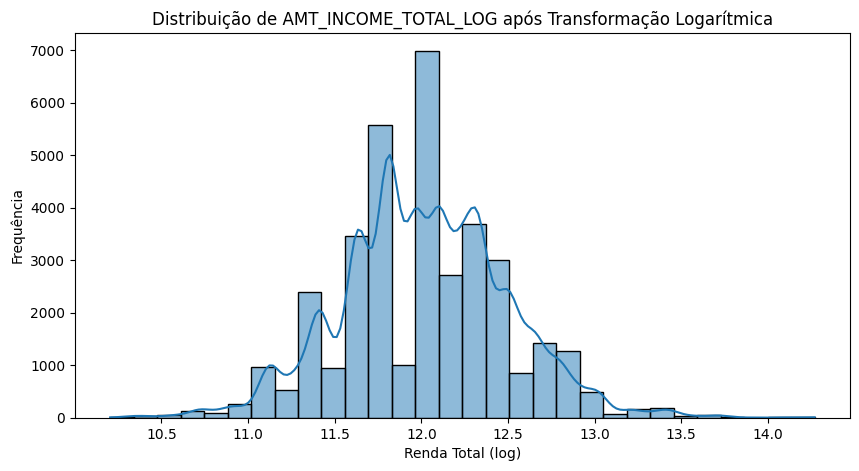

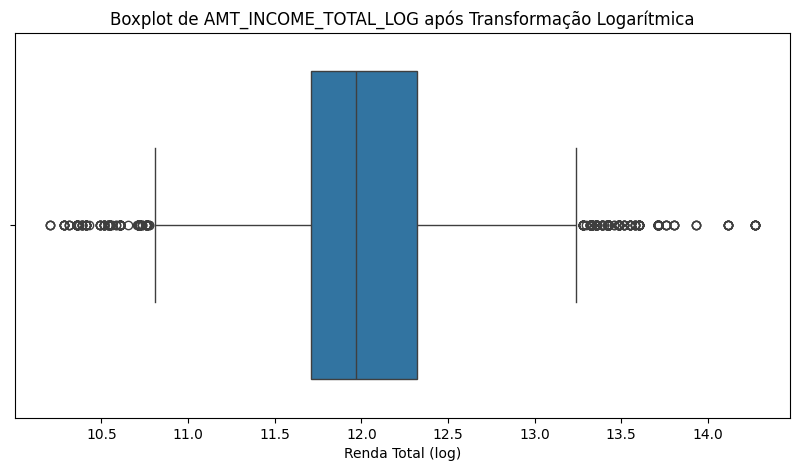

In [219]:
# Aplicar transformação logarítmica (log1p para lidar com valores zero, se existirem)
df_final['AMT_INCOME_TOTAL_LOG'] = np.log1p(df_final['AMT_INCOME_TOTAL'])

print("Estatísticas descritivas de AMT_INCOME_TOTAL_LOG após transformação logarítmica:")
display(df_final['AMT_INCOME_TOTAL_LOG'].describe())

# Visualizar a distribuição após o tratamento
plt.figure(figsize=(10, 5))
sns.histplot(df_final['AMT_INCOME_TOTAL_LOG'], bins=30, kde=True)
plt.title('Distribuição de AMT_INCOME_TOTAL_LOG após Transformação Logarítmica')
plt.xlabel('Renda Total (log)')
plt.ylabel('Frequência')
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x=df_final['AMT_INCOME_TOTAL_LOG'])
plt.title('Boxplot de AMT_INCOME_TOTAL_LOG após Transformação Logarítmica')
plt.xlabel('Renda Total (log)')
plt.show()

Após a aplicação da transformação logarítmica (np.log1p), a distribuição de AMT_INCOME_TOTAL (agora AMT_INCOME_TOTAL_LOG) tornou-se visivelmente mais simétrica e próxima de uma distribuição normal. O histograma mostra uma forma mais equilibrada, e o boxplot indica uma redução significativa na dispersão dos outliers, que foram trazidos para mais perto do corpo principal da distribuição. Essa transformação é fundamental para garantir que a variável contribua de forma mais eficaz e menos enviesada nos modelos preditivos.

## 5. Balanceamento de classes

**Interpretação:** _qual a proporção entre as classes e o que isso implica na escolha das métricas?_

A distribuição observada de `TARGET` é aproximadamente equilibrada: cerca de **53,45%** dos clientes foram classificados como bons pagadores (`0`) e **46,55%** como maus pagadores (`1`). Portanto, não há um desbalanceamento severo que justifique aplicar oversampling ou undersampling automaticamente nesta etapa.

Mesmo assim, a acurácia não deve ser usada isoladamente. A avaliação deve incluir **precision**, **recall**, **F1-score**, **ROC-AUC** e a **matriz de confusão**, principalmente porque identificar corretamente os maus pagadores é o objetivo de risco mais sensível. A proporção de classes deve ser recalculada após qualquer filtragem ou divisão da base.

O balanceamento artificial não foi aplicado na EDA para evitar vazamento de dados. Caso os experimentos de modelagem indiquem necessidade, técnicas como `class_weight="balanced"` ou SMOTE devem ser aplicadas somente dentro do pipeline e exclusivamente nos dados de treino. Também é importante observar que `TARGET` foi construído a partir das variáveis históricas de crédito; por isso, as correlações altas entre `TARGET` e `LATE_*`, `WORST_LATE`, `TOTAL_LATES` e `LATE_RATE` refletem a própria regra de rotulagem e não devem ser interpretadas como evidência independente.

## 6. Síntese da EDA

_Amarre os achados em uma narrativa única — é ela que vira o storytelling da apresentação._

**Análise Exploratória de Dados: Entendendo o Risco de Crédito**

O objetivo é classificar os clientes entre bons e maus pagadores a partir das informações cadastrais e do histórico de crédito. A base de aplicação reúne características demográficas, financeiras e de emprego; a base de crédito foi consolidada por `ID` para representar o comportamento de cada cliente em uma única linha.

#### **1. Consolidação e preparação dos dados**

Foram tratados valores ausentes de `OCCUPATION_TYPE`, o código especial de `DAYS_EMPLOYED` e as variáveis derivadas `YEARS_BIRTH`, `YEARS_EMPLOYED` e `IS_INACTIVE`. O histórico mensal foi transformado em indicadores de recência, gravidade e frequência: `LATE_3M`, `LATE_6M`, `LATE_9M`, `LATE_12M`, `WORST_LATE`, `LAST_LATE`, `HIST_LENGTH`, `TOTAL_LATES` e `LATE_RATE`.

#### **2. Variável alvo e balanceamento**

A variável `TARGET` é definida por regras baseadas no status atual, no pior atraso, na recência e na taxa de atrasos. Na amostra integrada, aproximadamente 53,45% dos clientes são bons pagadores (`0`) e 46,55% são maus pagadores (`1`), caracterizando uma distribuição próxima do equilíbrio, e não o desbalanceamento severo descrito em uma versão anterior.

Por essa razão, não foi aplicado reamostramento na EDA. Na modelagem, a avaliação deve combinar precision, recall, F1-score, ROC-AUC e matriz de confusão. Qualquer SMOTE, undersampling ou ajuste de pesos deve ser aplicado somente dentro do pipeline de treino para evitar vazamento.

#### **3. Outliers e transformações**

A análise de outliers foi restrita a variáveis contínuas e de contagem: `CNT_CHILDREN`, `AMT_INCOME_TOTAL`, `CNT_FAM_MEMBERS`, `YEARS_BIRTH`, `YEARS_EMPLOYED`, `LAST_LATE`, `HIST_LENGTH`, `TOTAL_LATES` e `LATE_RATE`. IDs, flags, `TARGET`, `WORST_LATE` e as flags binárias `LATE_*` não são candidatos adequados à regra do IQR.

Foi aplicado capping seletivo às contagens de filhos e membros da família. A renda também recebeu a transformação `AMT_INCOME_TOTAL_LOG`. Os indicadores de atraso foram preservados, pois valores altos, maior gravidade e atrasos recentes representam informação de risco, não erros de medição.

#### **4. Principais insights**

* `LATE_RATE`, `TOTAL_LATES`, `WORST_LATE` e as janelas `LATE_*` concentram as associações positivas mais importantes com `TARGET`.
* `LAST_LATE` exige interpretação cuidadosa, pois valores menores indicam atraso mais recente.
* Variáveis cadastrais como renda, idade, emprego, gênero e posse de bens apresentam associações lineares menores, embora possam contribuir em modelos não lineares ou em conjunto com outras variáveis.
* A predominância feminina, a concentração em ocupações conhecidas ou não informadas e a distribuição de renda e idade ajudam a contextualizar o perfil da carteira.

#### **Conclusão: dados prontos para a modelagem**

Após a limpeza, a consolidação do histórico e o tratamento seletivo de outliers, o conjunto está preparado para a modelagem. A leitura dos resultados deve considerar que `TARGET` foi construído a partir de variáveis de comportamento; portanto, as correlações elevadas entre o alvo e os indicadores de atraso confirmam a regra de rotulagem, mas não constituem evidência independente de causalidade.